In [1]:
# Description: Plot Figure 2 (Shelf edge seasonal climatology).
# Author:      André Palóczy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from xarray import open_dataset
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from gsw import grav, sigma0
import cartopy.crs as ccrs

proj = ccrs.PlateCarree()
from cartopy.feature import LAND
from cmocean.cm import thermal, haline, dense, balance

In [3]:
def near2(x, y, x0, y0):
    dr2 = (x - x0) ** 2 + (y - y0) ** 2
    return int(np.nanargmin(dr2))

## Set file paths, read EN4-based along-isobath climatology.

In [4]:
fname = "../proc/alongisob_seasonal_EN4_200m.nc"

ds = open_dataset(fname)
x, z = ds["x"], ds["z"]
zbot = z.values.min()

# Load Wei et al. (2024) sections.
xi, yi, di = ds["lon"].values, ds["lat"].values, ds["x"].values
xseg0, yseg0 = np.loadtxt("../proc/segment_latitudes_wei_etal2024.txt", unpack=True)
fseg = [near2(xi, yi, xseg0[i], yseg0[i]) for i in range(len(yseg0))]
fseg[0] = 0
fseg[-1] = -1
xseg, yseg = xi[fseg], yi[fseg]
dibound = di[fseg]

txt_segs = ["AS", "CSS", "PSBS", "MS", "HS", "WSS", "NENSS"]

def annotate_segments(axs, dibound=dibound, txt_segs=txt_segs, ytxt=-100, lineplot=False,
    add_segnames=True):
    if lineplot:
        ytxt = -10
    for axi in axs:
        _ = [axi.axvline(x=dd, color="k", linestyle="--", linewidth=1.5, zorder=99999998)
            for dd in dibound[1:-1]]
        if add_segnames:
            for i in range(len(txt_segs)):
                xtxt = 0.5 * (dibound[i] + dibound[i + 1])
                txt_segsi = str(i + 1) + "-" + txt_segs[i]
                axi.text(xtxt, ytxt, txt_segsi, ha="center", va="center", rotation=90, fontsize=14, color="k", zorder=99999999)

getfattr: Removing leading '/' from absolute path names


### Calculate local potential energy anomaly (PEA) and depth-averaged along-isobath density gradient magnitude.

In [5]:
# Potential Energy Anomaly:
rhoaux = ds["rho"].copy()
nt = rhoaux.sizes["t"]
nx = rhoaux.sizes["x"]
h = ds["rho"].isel(z=-1) * np.nan

for n in range(nt):
    for i in range(nx):
        rhoauxi = rhoaux.isel(t=n, x=i).values
        if np.isnan(rhoauxi).any():
            fnan = np.where(np.isnan(rhoauxi))[0]
            assert z[fnan[0]] < -100, "Top NaN is too shallow"
            h.values[n, i] = z[fnan[0]]
        else:
            h.values[n, i] = zbot

rho0 = 1027.5  # [kg/m3]
g = grav(ds["lat"].values, 0).mean()  # [m/s^2]
dz = z.values[1] - z.values[0]

rhobar = sigma0(ds["SA"], ds["CT"]).mean("z") # Depth-average of the density profile.
PEA = -((rhoaux - rhobar) * z * dz).sum("z") * g / h  # [J/m3]

# Depth-averaged along-isobath density gradient magnitude.
# Average in segments and plot as dots by season on a right twinx(), to go with the PEA(x) plots.
rho = ds["rho"]
drhody_mag = np.abs(rho.differentiate("x"))  # Magnitude of the along-isobath density gradient [kg/m3/km]
drhody_zavg = (drhody_mag * dz).sum("z") / h  # Depth-averaged |drho/dy| [kg/m3/km]
drhody_xzavg = drhody_zavg.mean("x")  # [kg/m3/km]

In [6]:
head = "../proc/en4_xyNWES-"

ssns = ["annual", "JFM", "AMJ", "JAS", "OND"]
lons_all, lats_all = dict(), dict()
lons, lats = dict(), dict()
for ssn in ssns:
    d_all = np.load(head + "%s_all.npz" % ssn)
    d = np.load(head + "%s.npz" % ssn)
    lons_all.update({ssn: d_all["lon"]})
    lats_all.update({ssn: d_all["lat"]})
    lons.update({ssn: d["lon"]})
    lats.update({ssn: d["lat"]})

xmin, xmax = -16.5, 10.5
ymin, ymax = 44, 63

bb = (xmin, xmax, ymin, ymax)
isobs = [200, 1000]

Tmin, Smin, Dmin = 6, 33, 25.4
Tmax, Smax, Dmax = 18, 35.7, 27.4
dTmax, dSmax, drhomax = 4, 0.5, 1

Dmin0, Dmax0 = 23.2, 27.5
Tiso = np.arange(Tmin, Tmax, 1)
Siso = np.arange(Smin, Smax, 0.2)
Diso = np.arange(Dmin0, Dmax0, 0.4)

fbathymetry = "../data/srtm15p/SRTM15_V2.7.nc"
dstopo = open_dataset(fbathymetry).sel(lon=slice(xmin, xmax), lat=slice(ymin, ymax))
xt, yt = np.meshgrid(dstopo["lon"].values, dstopo["lat"].values)
ht = -dstopo["z"].values

xtks = np.arange(xmin + 0.5, xmax, 6)
ytks = np.arange(ymin, ymax, 4)

getfattr: Removing leading '/' from absolute path names


## Plot Figure 2.


[annual] Along-isobath average PEA    : 83.22 J/m3
[annual] Along-isobath average |rho_y|: 0.67 1e-3 kg/m3/km

[JFM] Along-isobath average PEA    : 16.56 J/m3
[JFM] Along-isobath average |rho_y|: 0.49 1e-3 kg/m3/km

[AMJ] Along-isobath average PEA    : 65.09 J/m3
[AMJ] Along-isobath average |rho_y|: 0.62 1e-3 kg/m3/km

[JAS] Along-isobath average PEA    : 182.46 J/m3
[JAS] Along-isobath average |rho_y|: 0.87 1e-3 kg/m3/km

[OND] Along-isobath average PEA    : 92.32 J/m3
[OND] Along-isobath average |rho_y|: 0.79 1e-3 kg/m3/km


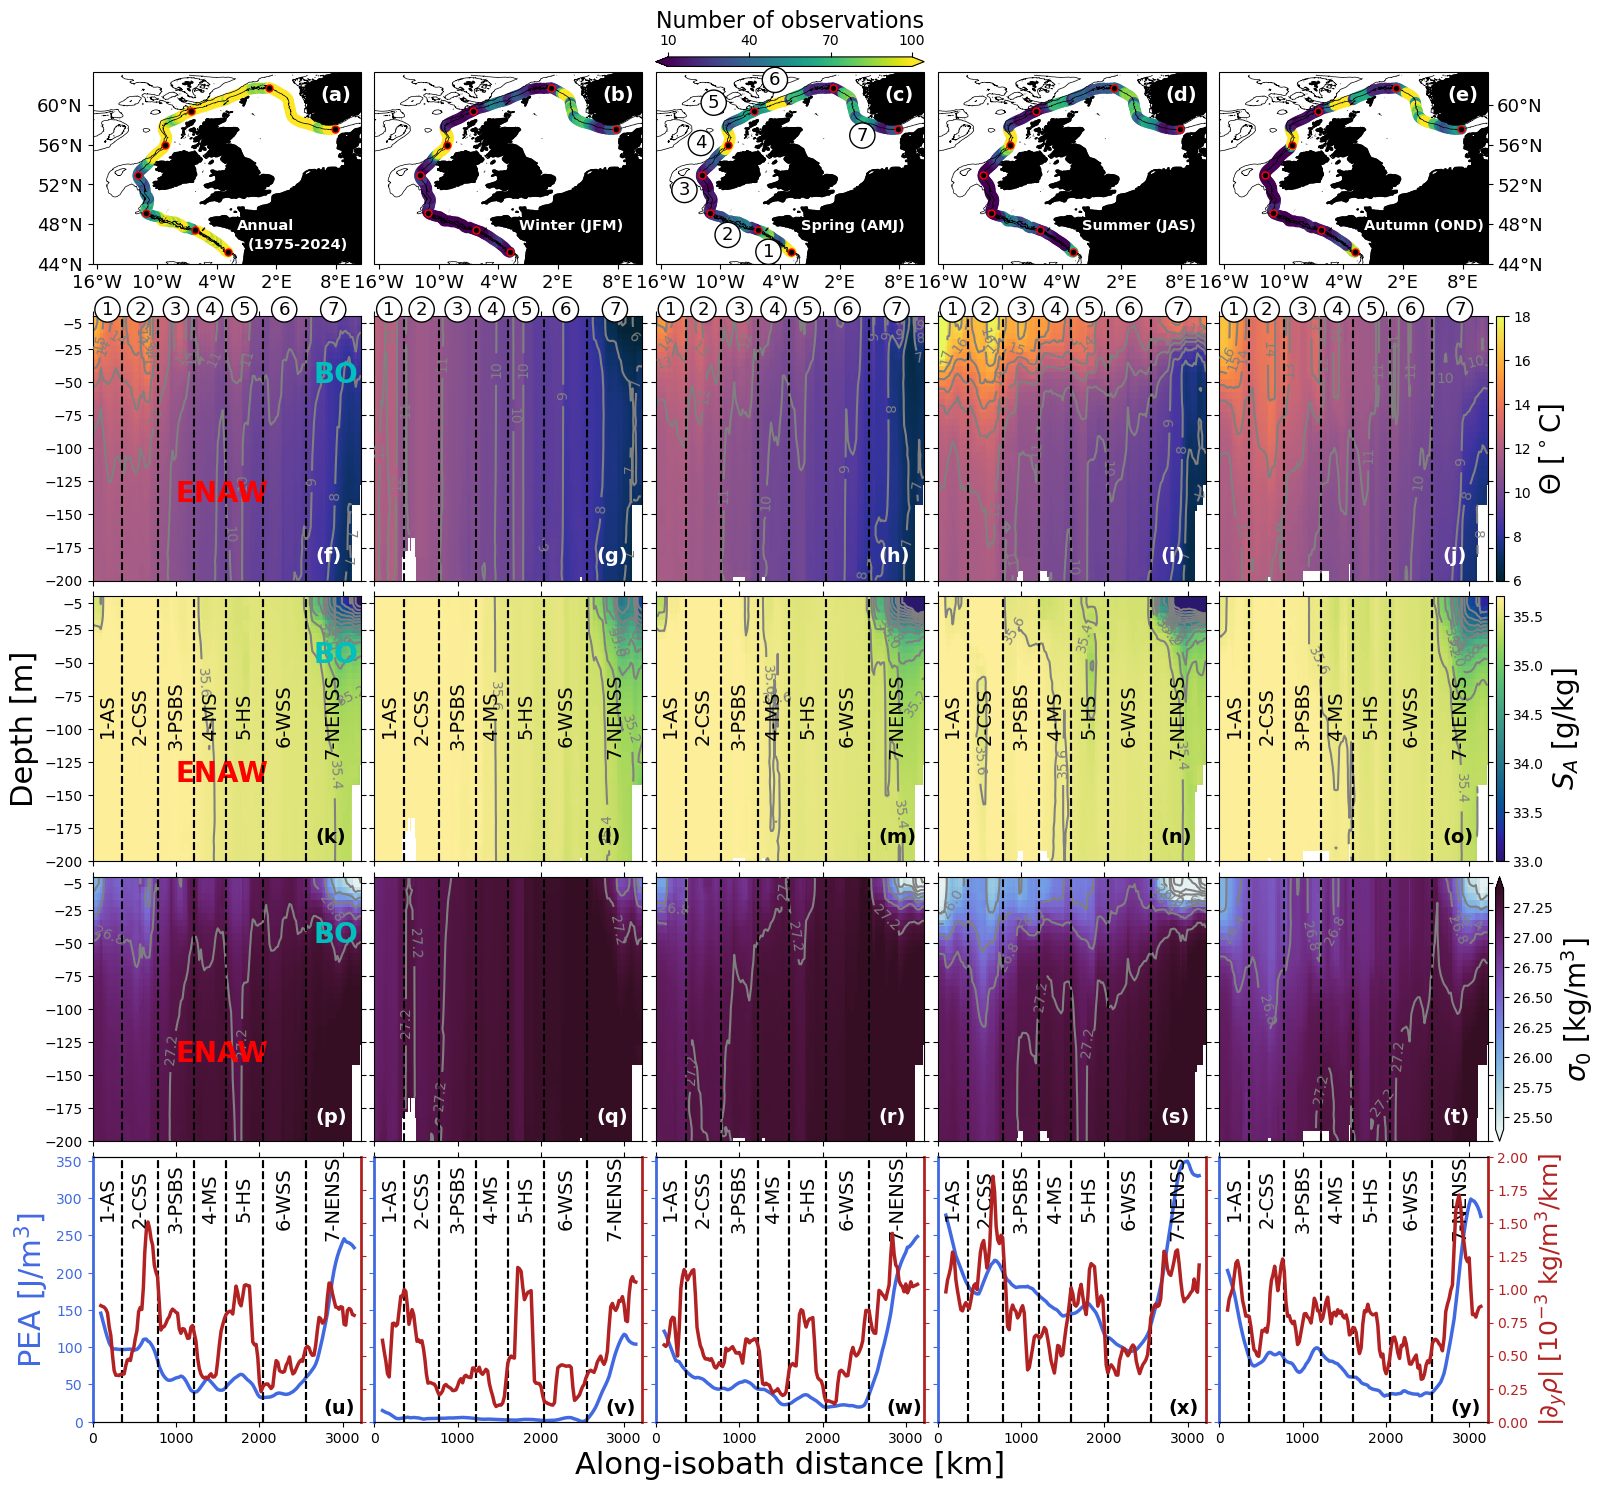

In [7]:
fig = plt.figure(figsize=(18, 18))
ncols, nrows = 5, 5
axs = []
bot_axrs = []

for row in range(nrows):
    row_axs = []
    for col in range(ncols):
        if row == 0:
            ax = fig.add_subplot(nrows, ncols, row * 5 + col + 1, projection=proj)
            if col == 0:
                ax.set_xticks(xtks, crs=proj)
                ax.set_yticks(ytks, crs=proj)
            elif col == (ncols - 1):
                ax.yaxis.set_ticks_position("right")
                ax.yaxis.set_label_position("right")
                ax.set_xticks(xtks, crs=proj)
                ax.set_yticks(ytks, crs=proj)
            else:
                ax.set_xticks(xtks, crs=proj)
                ax.set_yticks([], crs=proj)

            ax.xaxis.set_major_formatter(LONGITUDE_FORMATTER)
            ax.yaxis.set_major_formatter(LATITUDE_FORMATTER)
            ax.tick_params(axis="both", which="major", labelsize=13)
            ax.set_extent(bb)
            ax.coastlines(zorder=999)
            ax.add_feature(LAND, zorder=999, color="k")

            ax.contour(xt, yt, ht, isobs, colors="k", linewidths=0.5, zorder=997)  # Add bathymetry.
            # Add smoothed isobath and segment dots.
            ax.plot(xseg, yseg, linestyle="none", marker="o", ms=5, mfc="k", mec="r", zorder=999)

            ssn = ssns[col]
            xp, yp = lons[ssn], lats[ssn]

            # Number of data points averaged in each bin.
            CTi = ds["CT_n"].isel(t=col) # Annual, JFM, AMJ, JAS, OND.
            SAi = ds["SA_n"].isel(t=col) # Annual, JFM, AMJ, JAS, OND.
            nptsi = np.nanmean(np.minimum(CTi.values, SAi.values), axis=0) # Vertical mean of valid points used in each bin.
            nptmin, nptmax = 10, 100
            csn = ax.scatter(xi, yi, c=nptsi, s=50, vmin=nptmin, vmax=nptmax, cmap=plt.cm.viridis)

        elif row == 1:  # CT
            CTi = ds["CT"].isel(t=col)  # Annual, JFM, AMJ, JAS, OND.
            ax = fig.add_subplot(nrows, ncols, row * 5 + col + 1)

            csT = ax.pcolormesh(x, z, CTi, vmin=Tmin, vmax=Tmax, cmap=thermal)
            cc = ax.contour(x, z, CTi, levels=Tiso, colors="gray")
            ax.clabel(cc, fmt="%d")

        elif row == 2:  # SA
            SAi = ds["SA"].isel(t=col)  # Annual, JFM, AMJ, JAS, OND.
            ax = fig.add_subplot(nrows, ncols, row * 5 + col + 1)

            csS = ax.pcolormesh(x, z, SAi, vmin=Smin, vmax=Smax, cmap=haline)
            cc = ax.contour(x, z, SAi, levels=Siso, colors="gray")
            ax.clabel(cc, fmt="%1.1f")

        elif row == 3:  # rho
            rhoi = ds["rho"].isel(t=col)  # Annual, JFM, AMJ, JAS, OND.
            ax = fig.add_subplot(nrows, ncols, row * 5 + col + 1)

            csD = ax.pcolormesh(x, z, rhoi, vmin=Dmin, vmax=Dmax, cmap=dense)
            cc = ax.contour(x, z, rhoi, levels=Diso, colors="gray")
            ax.clabel(cc, fmt="%1.1f")

        elif row == 4:  # PEA and |drho/dy|
            print("")
            ax = fig.add_subplot(nrows, ncols, row * 5 + col + 1)
            nwin = 10

            # PEAi = PEA.isel(t=col)
            PEAi = PEA.isel(t=col).rolling(x=nwin, center=True).mean().dropna(dim="x")
            x_win = PEAi["x"].values
            PEAi = PEAi.values

            # drhody_zavgi = drhody_zavg.isel(t=col)
            drhody_zavgi = (drhody_zavg.isel(t=col).rolling(x=nwin, center=True).mean().dropna(dim="x"))

            drhody_zavgi = drhody_zavgi.values * 1e3

            ax.plot(x_win, PEAi, color="royalblue", linewidth=2.5, zorder=2)
            axr = ax.twinx()
            axr.plot(x_win, drhody_zavgi, color="firebrick", linewidth=2.5, zorder=1)

            bot_axrs.append(axr)

            # Print along-isobath average PEA and |drhody|:
            ssn = ssns[col]
            print("[%s] Along-isobath average PEA    : %1.2f J/m3"%(ssn, np.nanmean(PEAi)))
            print("[%s] Along-isobath average |rho_y|: %1.2f 1e-3 kg/m3/km"%(ssn, np.nanmean(drhody_zavgi)))

        if col == 0 and row == 2:
            ax.set_ylabel(r"Depth [m]", fontsize=22)
        elif col == 0 and row == 4:
            ax.set_ylabel(r"PEA [J/m$^3$]", fontsize=22, color="royalblue")
        elif col == 4 and row == 4:
            axr.set_ylabel(r"$|\partial_y\rho|$ [$10^{-3}$ kg/m$^3$/km]", fontsize=18, color="firebrick")

        if row > 0:
            ax.tick_params(axis="both", direction="out")
            if row < (nrows - 1):
                ztks = np.append(np.arange(-200, 0, 25), -5)
                ax.set_yticks(ztks)
                if col > 0:
                    ax.set_yticklabels([])

                ax.set_xticklabels([])

        row_axs.append(ax)
    axs.append(row_axs)

xr = x.values[-1]
_ = [axi.tick_params(axis="both", which="both", left=True, bottom=True, right=True, top=True) for axi in np.array(axs[1:]).ravel()]

for axi in bot_axrs[:-1]:
    axi.set_yticklabels([])

for j in range(1, nrows):
    for i in range(ncols):
        if j < (nrows - 1):
            axs[j][i].set_ylim(-200, 0)
        else:
            axs[j][i].set_ylim(0, 355)
            bot_axrs[i].set_ylim(0, 2)
            if i > 0:
                axs[j][i].set_yticklabels([])
        axs[j][i].set_xlim(0, xr)

for i in range(ncols):
    axs[-1][i].tick_params(axis="y", which="both", right=False, labelright=False)
    bot_axrs[i].tick_params(axis="y", which="both", left=False, labelleft=False)

    bot_axrs[i].spines["left"].set_visible(False)
    bot_axrs[i].spines["right"].set_color("firebrick")
    bot_axrs[i].spines["right"].set_linewidth(2)
    bot_axrs[i].yaxis.label.set_color("firebrick")
    bot_axrs[i].tick_params(axis="y", colors="firebrick")

    axs[-1][i].spines["right"].set_visible(False)
    axs[-1][i].spines["left"].set_color("royalblue")
    axs[-1][i].spines["left"].set_linewidth(2)
    axs[-1][i].yaxis.label.set_color("royalblue")
    axs[-1][i].tick_params(axis="y", colors="royalblue")

annotate_segments(np.array(axs[1:]).ravel(), add_segnames=False)
annotate_segments(np.array(axs[2]).ravel(), add_segnames=True, ytxt=-90)
annotate_segments(np.array(axs[4]).ravel(), add_segnames=True, ytxt=300)

xysegnums = [
    (-5.750592115565283, 44.7),
    (-9.859370106482896, 46.4),
    (-14.205708777012163, 50.91878754137185),
    (-12.554278891324728, 55.646525151968326),
    (-11.260467233009667, 59.705552535108104),
    (-5.1, 62),
    (3.7, 56.4),
]

# Add text labels for each segment's number on top of the shelf-edge plots and on the maps.
fig.subplots_adjust(hspace=0.06, wspace=0.05)

bbkw = dict(boxstyle="circle,pad=0.2", fc="w", ec="k", lw=1)
ytxt2 = 5  # [m]
axtxts, axtxts2 = axs[0], axs[1]
axtxts = [axtxts[2]]
for n, xytxt in enumerate(xysegnums):
    xtxt, ytxt = xytxt
    xtxt2 = 0.5 * (dibound[n] + dibound[n + 1])
    _ = [axi.text(xtxt, ytxt, str(n + 1), fontsize=13, color="k", bbox=bbkw, zorder=9999) for axi in axtxts]
    _ = [axi.text(xtxt2, ytxt2, str(n + 1), ha="center", va="center", fontsize=13, color="k", bbox=bbkw, zorder=9999) for axi in axtxts2]

# Add panel letters.
c1, c2 = "w", "k"
letters = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y"]

row1 = "abcde"
rows35 = "klmnouvwxy"
row5 = "uvwxy"
for i, letter, axi in zip(range(len(letters)), letters, np.array(axs).ravel()):
    if letter in rows35:
        c = c2
    else:
        c = c1

    if letter in row1:
        xtxt, ytxt = 0.85, 0.85
    elif letter in row5:
        xtxt, ytxt = 0.86, 0.03
    else:
        xtxt, ytxt = 0.83, 0.07

    axi.text(xtxt, ytxt, "(" + letter + ")", fontsize=14, fontweight="black", color=c, transform=axi.transAxes, zorder=9999)

# Water mass annotations.
xtxt, ytxt = 1000, -140
_ = [axs[i][0].text(xtxt, ytxt, "ENAW", color="r", fontsize=20, fontweight="black", zorder=99999) for i in [1, 2, 3]]

xtxt, ytxt = 2650, -50
_ = [axs[i][0].text(xtxt, ytxt, "BO", color="c", fontsize=20, fontweight="black", zorder=99999) for i in [1, 2, 3]]

# Colorbars
axn, axT, axS, axD = axs[0][2], axs[1][-1], axs[2][-1], axs[3][-1]
cbax0 = [0, 1.03, 1, 0.05]
cbax = [1.03, 0, 0.03, 1]
caxn, caxT, caxS, caxD = axn.inset_axes(cbax0), axT.inset_axes(cbax), axS.inset_axes(cbax), axD.inset_axes(cbax)
cbn = fig.colorbar(csn, cax=caxn, orientation="horizontal", extend="both")
cbT = fig.colorbar(csT, cax=caxT, orientation="vertical")
cbS = fig.colorbar(csS, cax=caxS, orientation="vertical")
cbD = fig.colorbar(csD, cax=caxD, orientation="vertical", extend="both")


cbn.ax.xaxis.set_ticks_position("top"); cbn.ax.xaxis.set_label_position("top")
ntks = np.linspace(nptmin, nptmax, 4)
cbn.ax.xaxis.set_ticks(ntks)
cbn.set_label(r"Number of observations", size=16)
cbT.set_label(r"$\Theta$ [$^\circ$C]", size=20)
cbS.set_label(r"$S_A$ [g/kg]", size=20)
cbD.set_label(r"$\sigma_0$ [kg/m$^3$]", size=20)

xtxt, ytxt = 0.54, 0.18
axttl = axs[0]
axttl[0].text(xtxt, ytxt, r"Annual", color="w", fontsize=10.5, fontweight="black", transform=axttl[0].transAxes, zorder=999)

axttl[0].text(xtxt + 0.04, ytxt - 0.1, r"(1975-2024)", color="w", fontsize=10.5, fontweight="black", transform=axttl[0].transAxes, zorder=999)
axttl[1].text(xtxt, ytxt, r"Winter (JFM)", color="w", fontsize=10.5, fontweight="black", transform=axttl[1].transAxes, zorder=999)
axttl[2].text(xtxt, ytxt, r"Spring (AMJ)", color="w", fontsize=10.5, fontweight="black", transform=axttl[2].transAxes, zorder=999)
axttl[3].text(xtxt, ytxt, r"Summer (JAS)", color="w", fontsize=10.5, fontweight="black", transform=axttl[3].transAxes, zorder=999)
axttl[4].text(xtxt, ytxt, r"Autumn (OND)", color="w", fontsize=10.5, fontweight="black", transform=axttl[4].transAxes, zorder=999)
axs[-1][-3].set_xlabel(r"Along-isobath distance [km]", fontsize=22);

In [8]:
fig.savefig("fig2.png", bbox_inches="tight")